<a href="https://colab.research.google.com/github/dalyszz/data-science-project/blob/main/Health_Disparities_Dalys_Cleaned_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataframe Import

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving alzheimers_clean.xlsx to alzheimers_clean.xlsx


# Cleaning

In [ ]:
import pandas as pd

df = pd.read_excel("alzheimers_clean.xlsx")

In [ ]:
df.head()

,Year,StateAbbr,State,Class,Topic,Question,Data_Value_Unit,DataValueTypeID,Data_Value_Type,Data_Value,AgeGroup,DemographicCategory,Demographic
0,2015,GU,Guam,Overall Health,Recent activity limitations in past month,Mean number of days with activity limitations ...,Number,MEAN,Mean,5.9,Overall,Sex,Female
1,2015,MA,Massachusetts,Mental Health,Lifetime diagnosis of depression,Percentage of older adults with a lifetime dia...,%,PRCTG,Percentage,13.0,65 years or older,Sex,Male
2,2015,MDW,Midwest,Overall Health,Arthritis among older adults,Percentage of older adults ever told they have...,%,PRCTG,Percentage,32.0,50-64 years,Sex,Male
3,2015,MN,Minnesota,Mental Health,Frequent mental distress,Percentage of older adults who are experiencin...,%,PRCTG,Percentage,5.8,Overall,Sex,Male
4,2015,MO,Missouri,Overall Health,Arthritis among older adults,Percentage of older adults ever told they have...,%,PRCTG,Percentage,46.8,Overall,NaN,NaN


In [ ]:
df.columns = ([
    'Year','State Abbreviated', 'State', 'Class','Topic','Question','Data Value Unit',
    'Data Value Type ID',
    'Data Value Type','Data Value', 'Age Group','Demographic Category',
    'Demographic'
])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284142 entries, 0 to 284141
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Year                  284142 non-null  int64  
 1   State Abbreviated     284142 non-null  object 
 2   State                 284142 non-null  object 
 3   Class                 284142 non-null  object 
 4   Topic                 284142 non-null  object 
 5   Question              284142 non-null  object 
 6   Data Value Unit       284142 non-null  object 
 7   Data Value Type ID    284142 non-null  object 
 8   Data Value Type       284142 non-null  object 
 9   Data Value            192808 non-null  float64
 10  Age Group             284142 non-null  object 
 11  Demographic Category  247269 non-null  object 
 12  Demographic           247269 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 28.2+ MB


In [ ]:
columns_to_drop = [
    'State Abbreviated',
    'Data Value Unit',
    'Data Value Type ID',
    'Demographic Category'
]

df = df.drop(columns=columns_to_drop)

In [ ]:
df.dropna(
    subset=["Demographic", "Data Value"],
    inplace=True
)

# Filtering the Data

In [ ]:
conditions = [
    "Binge drinking within past 30 days",
    "Current smoking",
    "Functional difficulties associated with subjective cognitive decline or memory loss among older adults",
    "Arthritis among older adults",
    "Lifetime diagnosis of depression",
    "Obesity"
]

filtered_df = df[df["Topic"].isin(conditions)]

In [ ]:
filtered_df = filtered_df[
    filtered_df["Age Group"].isin([
        "50-64 years",
        "65 years or older"
    ])
]

In [ ]:
filtered_df = filtered_df[
    filtered_df["Demographic"] != "Overall"
]

In [ ]:
demographic_summary = filtered_df.groupby(["Topic", "Demographic"])["Data Value"].mean()

print(demographic_summary)

Topic                                                                                                   Demographic             
Arthritis among older adults                                                                            Asian/Pacific Islander      29.023881
                                                                                                        Black, non-Hispanic         45.897645
                                                                                                        Female                      47.767816
                                                                                                        Hispanic                    35.390860
                                                                                                        Male                        38.513997
                                                                                                        Native Am/Alaskan Native    46.821341
                   

# Bar Plots

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
def plot_topic(topic):
    health_data = filtered_df[filtered_df["Topic"] == topic]

    gender = health_data[health_data["Demographic"].isin(["Male", "Female"])]
    race = health_data[
        ~health_data["Demographic"].isin(["Male", "Female"])
    ]

    # Create two graphs in one figure
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # Left graph: Gender
    gender.groupby("Demographic")["Data Value"].mean().plot(
        kind="bar",
        ax=ax[0],
        color=["steelblue", "lightcoral"]
    )

    ax[0].set_title(f"{topic} by Gender")
    ax[0].set_ylabel("Average Data Value")
    ax[0].set_xlabel("Gender")
    ax[0].tick_params(axis="x", rotation=0)

    # Right graph: Race/Ethnicity
    race.groupby("Demographic")["Data Value"].mean().plot(
        kind="bar",
        ax=ax[1],
        color=["orange", "green", "purple", "red", "gold"]
    )

    ax[1].set_title(f"{topic} by Race/Ethnicity")
    ax[1].set_ylabel("Average Data Value")
    ax[1].set_xlabel("Race/Ethnicity")
    ax[1].tick_params(axis="x", rotation=45)

    # Adjust spacing
    plt.tight_layout()

    # Save the combined graph
    plt.savefig(f"{topic}_demographic_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

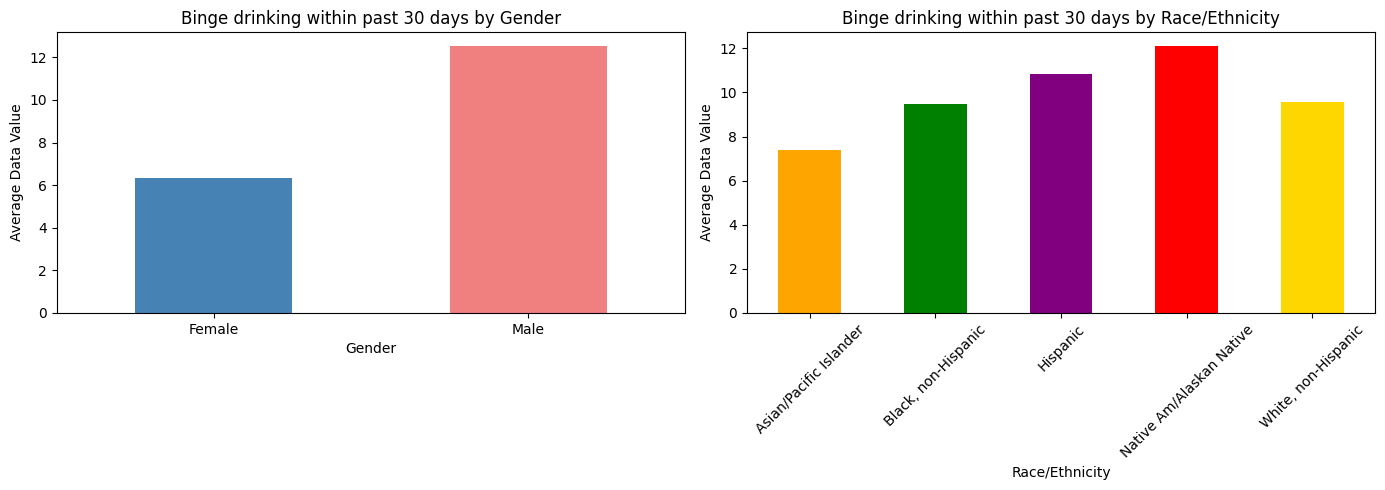

In [ ]:
plot_topic("Binge drinking within past 30 days")

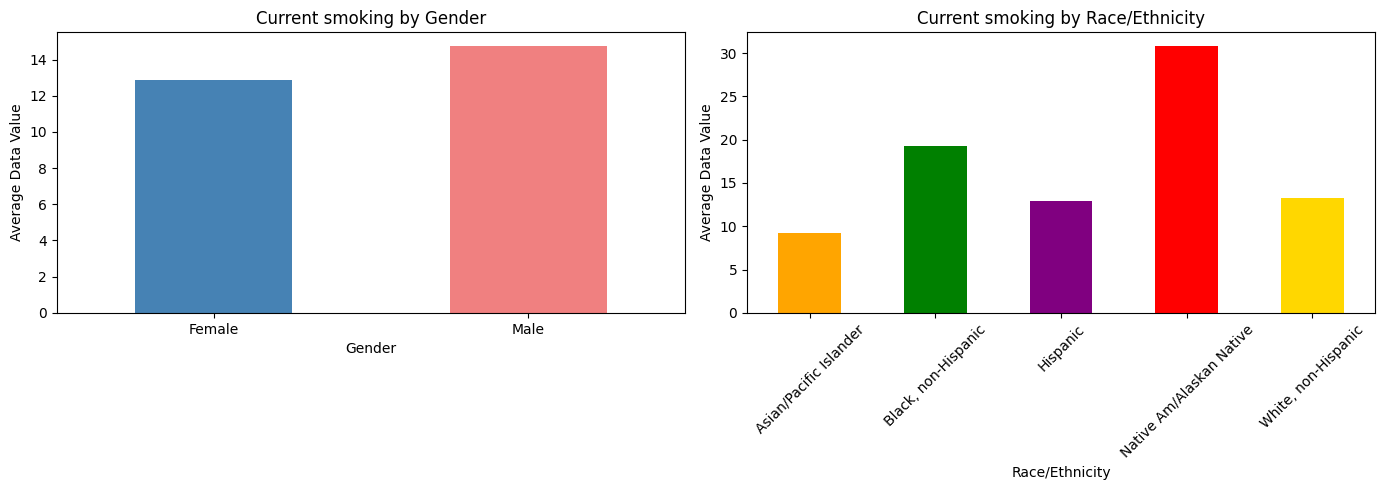

In [ ]:
plot_topic("Current smoking")

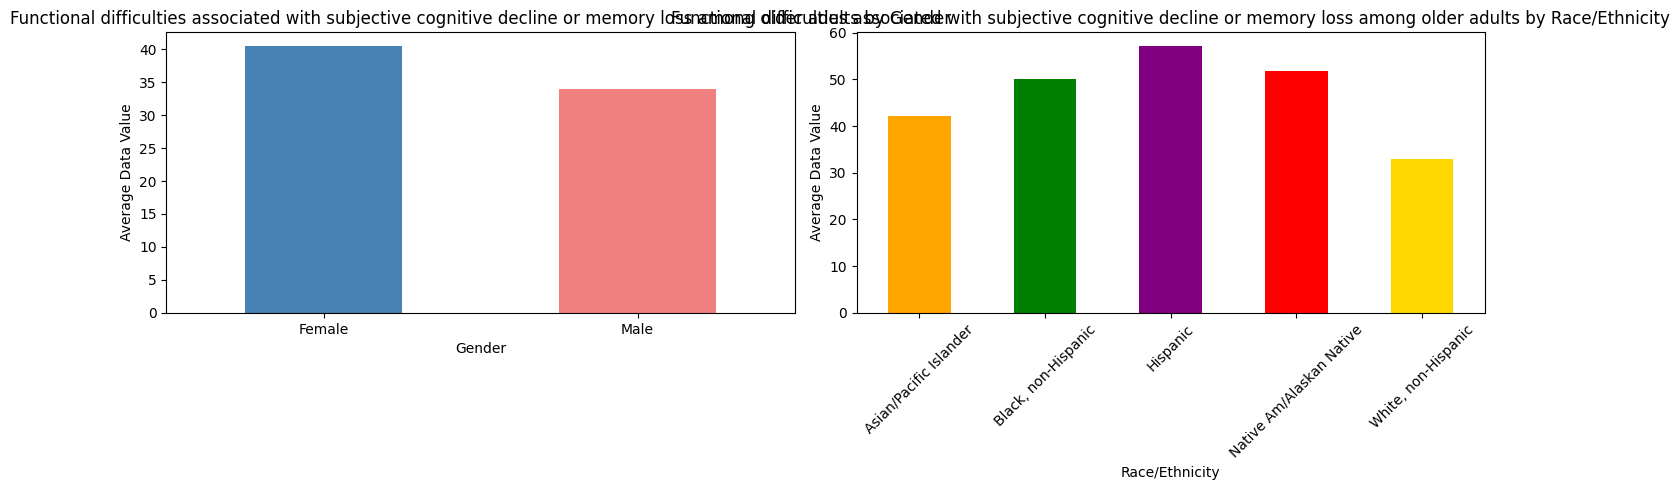

In [ ]:
plot_topic("Functional difficulties associated with subjective cognitive decline or memory loss among older adults")

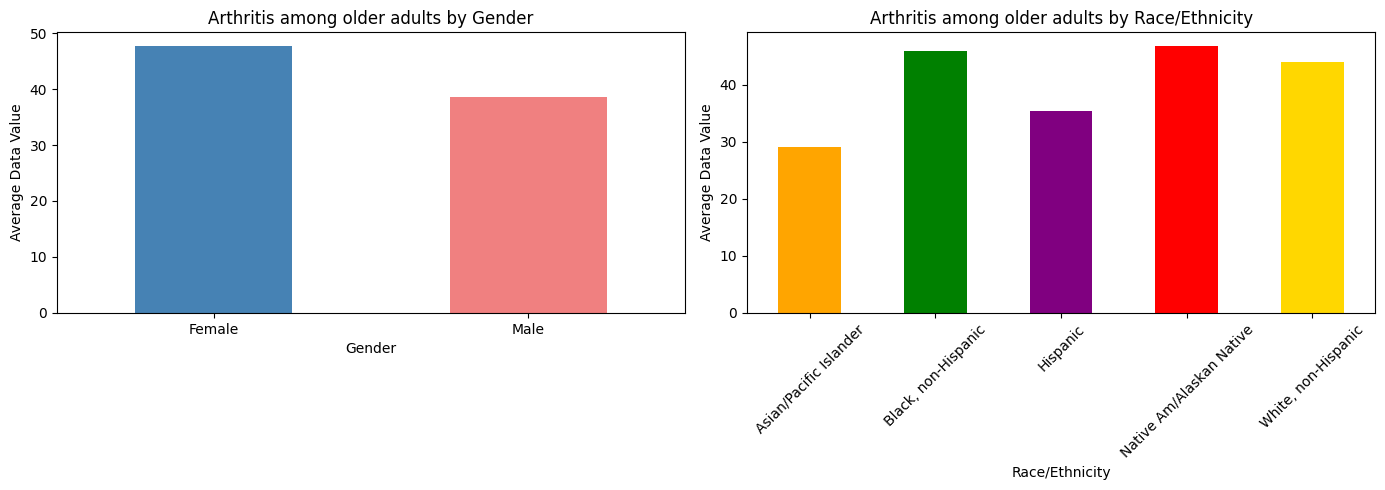

In [ ]:
plot_topic("Arthritis among older adults")

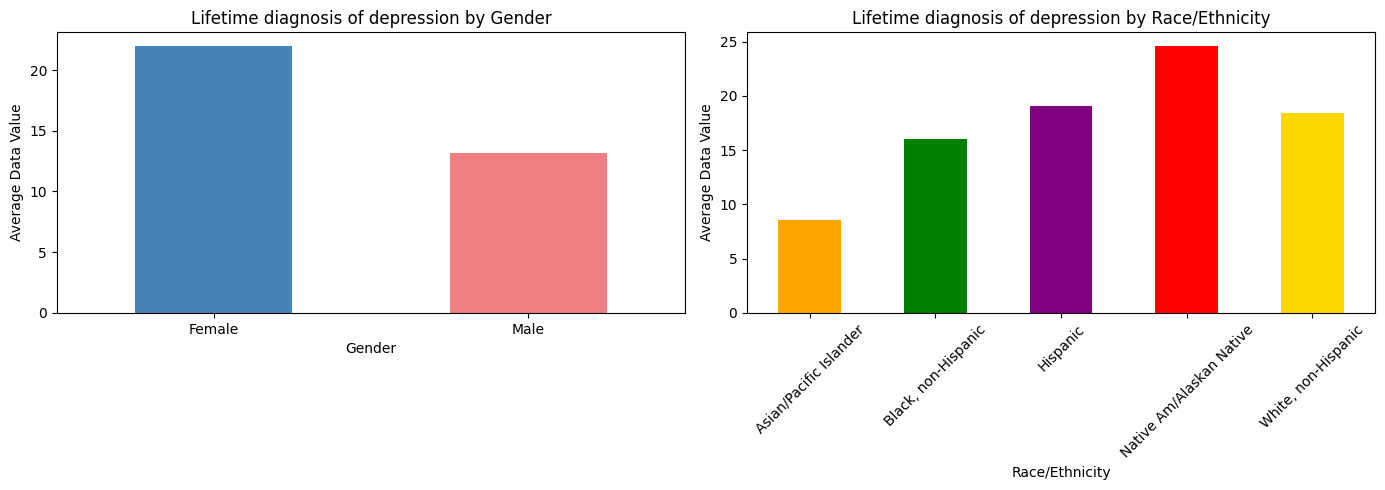

In [ ]:
plot_topic("Lifetime diagnosis of depression")

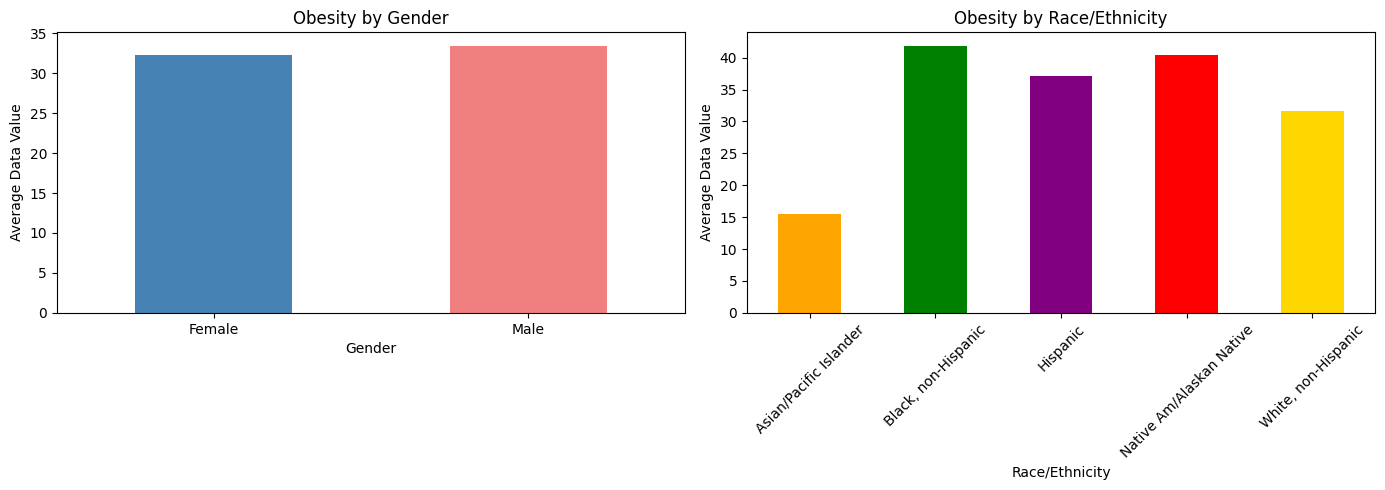

In [ ]:
plot_topic("Obesity")

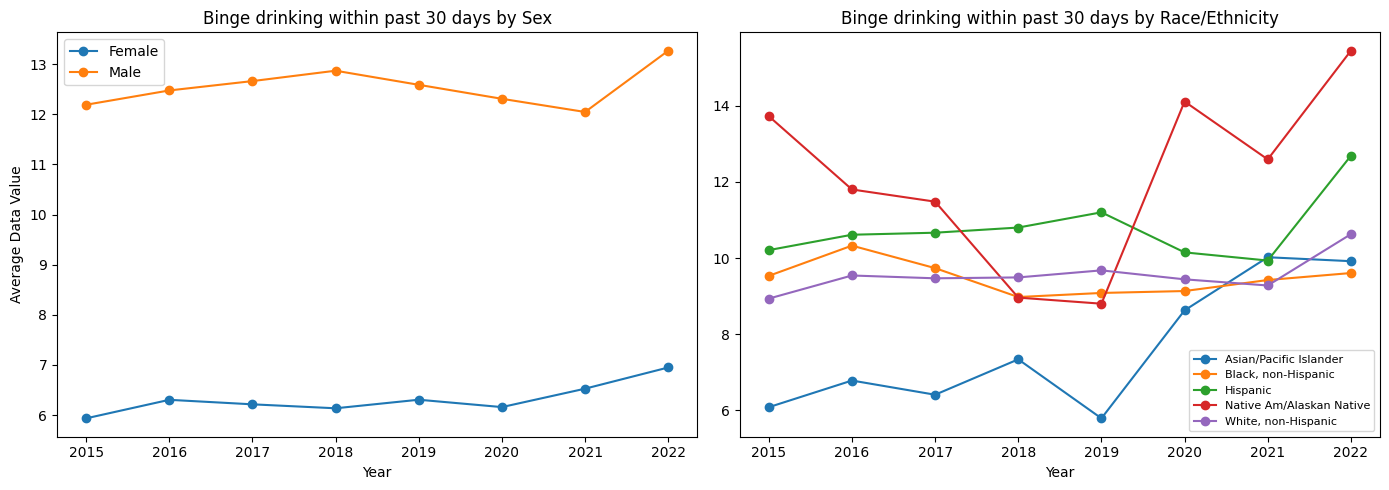

In [ ]:
# Choose one health condition
condition = "Binge drinking within past 30 days"

condition_df = filtered_df[filtered_df["Topic"] == condition]

# Separate the data
sex_df = condition_df[condition_df["Demographic"].isin(["Male", "Female"])]
race_df = condition_df[~condition_df["Demographic"].isin(["Male", "Female"])]

# Average by year
sex_year = sex_df.groupby(["Year", "Demographic"])["Data Value"].mean().reset_index()
race_year = race_df.groupby(["Year", "Demographic"])["Data Value"].mean().reset_index()

# Create two graphs in one figure
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Left graph: Male vs Female
for sex in sex_year["Demographic"].unique():
    temp = sex_year[sex_year["Demographic"] == sex]
    ax[0].plot(temp["Year"], temp["Data Value"], marker="o", label=sex)

ax[0].set_title("Binge drinking within past 30 days by Sex")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Average Data Value")
ax[0].legend()

# Right graph: Race/Ethnicity
for race in race_year["Demographic"].unique():
    temp = race_year[race_year["Demographic"] == race]
    ax[1].plot(temp["Year"], temp["Data Value"], marker="o", label=race)

ax[1].set_title("Binge drinking within past 30 days by Race/Ethnicity")
ax[1].set_xlabel("Year")
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{condition}_trend.png", dpi=300, bbox_inches="tight")
plt.show()

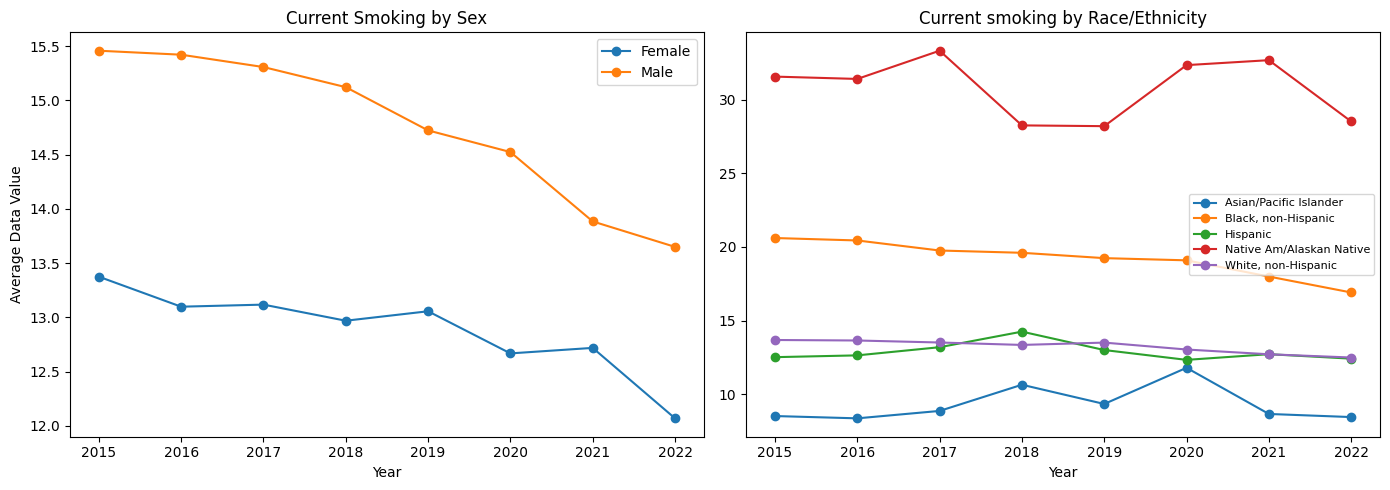

In [ ]:
# Choose one health condition
condition = "Current smoking"

condition_df = filtered_df[filtered_df["Topic"] == condition]

# Separate the data
sex_df = condition_df[condition_df["Demographic"].isin(["Male", "Female"])]
race_df = condition_df[~condition_df["Demographic"].isin(["Male", "Female"])]

# Average by year
sex_year = sex_df.groupby(["Year", "Demographic"])["Data Value"].mean().reset_index()
race_year = race_df.groupby(["Year", "Demographic"])["Data Value"].mean().reset_index()

# Create two graphs in one figure
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Left graph: Male vs Female
for sex in sex_year["Demographic"].unique():
    temp = sex_year[sex_year["Demographic"] == sex]
    ax[0].plot(temp["Year"], temp["Data Value"], marker="o", label=sex)

ax[0].set_title("Current Smoking by Sex")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Average Data Value")
ax[0].legend()

# Right graph: Race/Ethnicity
for race in race_year["Demographic"].unique():
    temp = race_year[race_year["Demographic"] == race]
    ax[1].plot(temp["Year"], temp["Data Value"], marker="o", label=race)

ax[1].set_title("Current smoking by Race/Ethnicity")
ax[1].set_xlabel("Year")
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{condition}_trend.png", dpi=300, bbox_inches="tight")
plt.show()

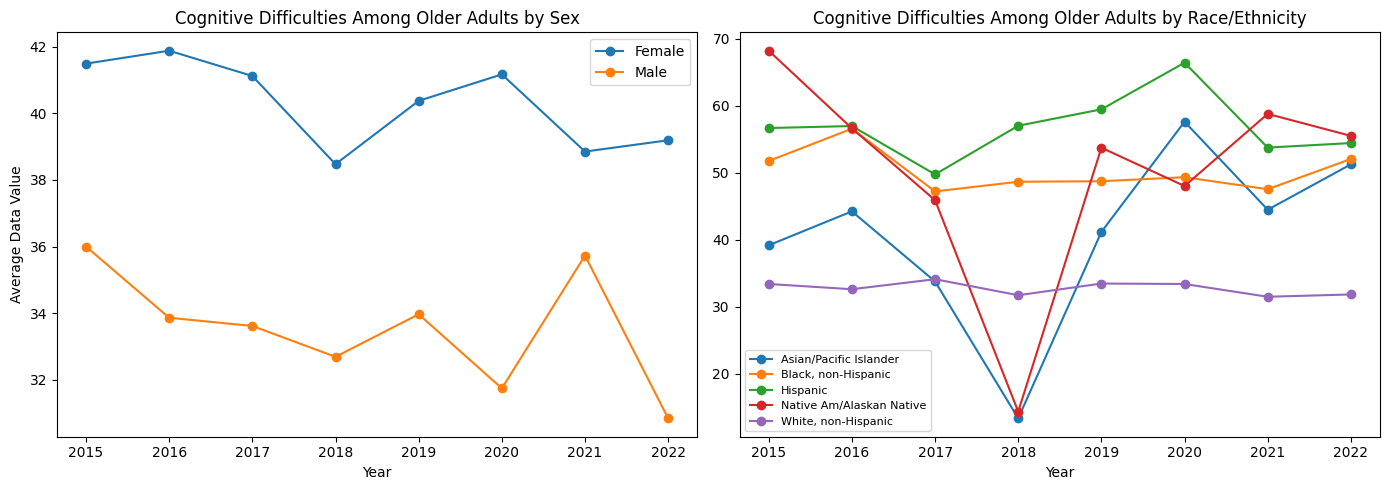

In [ ]:
# Choose one health condition
condition = "Functional difficulties associated with subjective cognitive decline or memory loss among older adults"

condition_df = filtered_df[filtered_df["Topic"] == condition]

# Separate the data
sex_df = condition_df[condition_df["Demographic"].isin(["Male", "Female"])]
race_df = condition_df[~condition_df["Demographic"].isin(["Male", "Female"])]

# Average by year
sex_year = sex_df.groupby(["Year", "Demographic"])["Data Value"].mean().reset_index()
race_year = race_df.groupby(["Year", "Demographic"])["Data Value"].mean().reset_index()

# Create two graphs in one figure
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Left graph: Male vs Female
for sex in sex_year["Demographic"].unique():
    temp = sex_year[sex_year["Demographic"] == sex]
    ax[0].plot(temp["Year"], temp["Data Value"], marker="o", label=sex)

ax[0].set_title("Cognitive Difficulties Among Older Adults by Sex")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Average Data Value")
ax[0].legend()

# Right graph: Race/Ethnicity
for race in race_year["Demographic"].unique():
    temp = race_year[race_year["Demographic"] == race]
    ax[1].plot(temp["Year"], temp["Data Value"], marker="o", label=race)

ax[1].set_title("Cognitive Difficulties Among Older Adults by Race/Ethnicity")
ax[1].set_xlabel("Year")
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{condition}_trend.png", dpi=300, bbox_inches="tight")
plt.show()

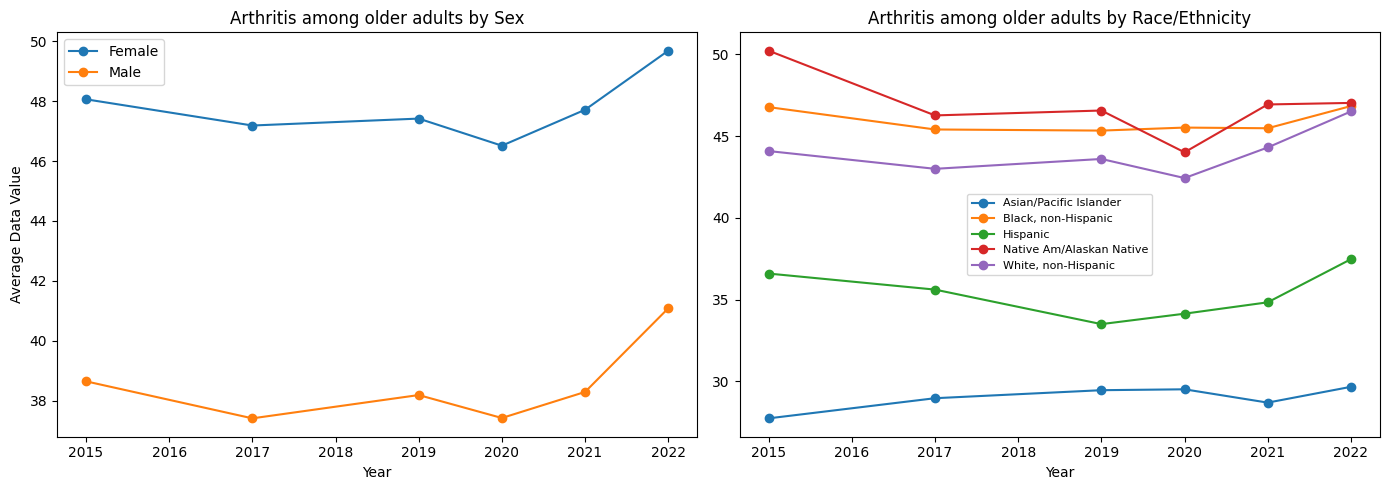

In [ ]:
# Choose one health condition
condition = "Arthritis among older adults"

condition_df = filtered_df[filtered_df["Topic"] == condition]

# Separate the data
sex_df = condition_df[condition_df["Demographic"].isin(["Male", "Female"])]
race_df = condition_df[~condition_df["Demographic"].isin(["Male", "Female"])]

# Average by year
sex_year = sex_df.groupby(["Year", "Demographic"])["Data Value"].mean().reset_index()
race_year = race_df.groupby(["Year", "Demographic"])["Data Value"].mean().reset_index()

# Create two graphs in one figure
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Left graph: Male vs Female
for sex in sex_year["Demographic"].unique():
    temp = sex_year[sex_year["Demographic"] == sex]
    ax[0].plot(temp["Year"], temp["Data Value"], marker="o", label=sex)

ax[0].set_title("Arthritis among older adults by Sex")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Average Data Value")
ax[0].legend()

# Right graph: Race/Ethnicity
for race in race_year["Demographic"].unique():
    temp = race_year[race_year["Demographic"] == race]
    ax[1].plot(temp["Year"], temp["Data Value"], marker="o", label=race)

ax[1].set_title("Arthritis among older adults by Race/Ethnicity")
ax[1].set_xlabel("Year")
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{condition}_trend.png", dpi=300, bbox_inches="tight")
plt.show()

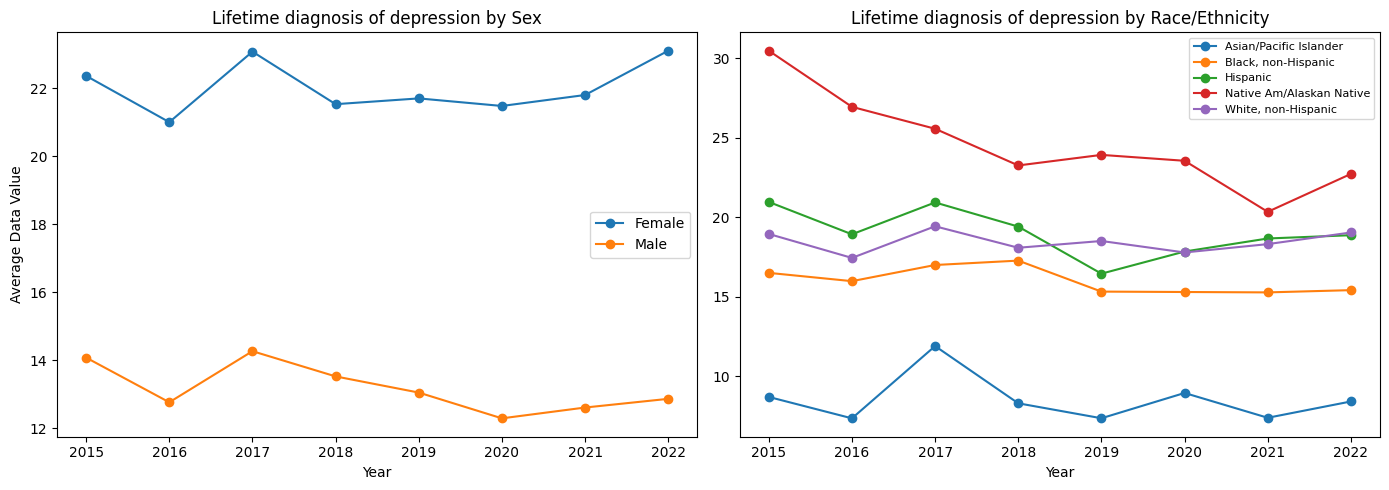

In [ ]:
# Choose one health condition
condition = "Lifetime diagnosis of depression"

condition_df = filtered_df[filtered_df["Topic"] == condition]

# Separate the data
sex_df = condition_df[condition_df["Demographic"].isin(["Male", "Female"])]
race_df = condition_df[~condition_df["Demographic"].isin(["Male", "Female"])]

# Average by year
sex_year = sex_df.groupby(["Year", "Demographic"])["Data Value"].mean().reset_index()
race_year = race_df.groupby(["Year", "Demographic"])["Data Value"].mean().reset_index()

# Create two graphs in one figure
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Left graph: Male vs Female
for sex in sex_year["Demographic"].unique():
    temp = sex_year[sex_year["Demographic"] == sex]
    ax[0].plot(temp["Year"], temp["Data Value"], marker="o", label=sex)

ax[0].set_title("Lifetime diagnosis of depression by Sex")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Average Data Value")
ax[0].legend()

# Right graph: Race/Ethnicity
for race in race_year["Demographic"].unique():
    temp = race_year[race_year["Demographic"] == race]
    ax[1].plot(temp["Year"], temp["Data Value"], marker="o", label=race)

ax[1].set_title("Lifetime diagnosis of depression by Race/Ethnicity")
ax[1].set_xlabel("Year")
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{condition}_trend.png", dpi=300, bbox_inches="tight")
plt.show()

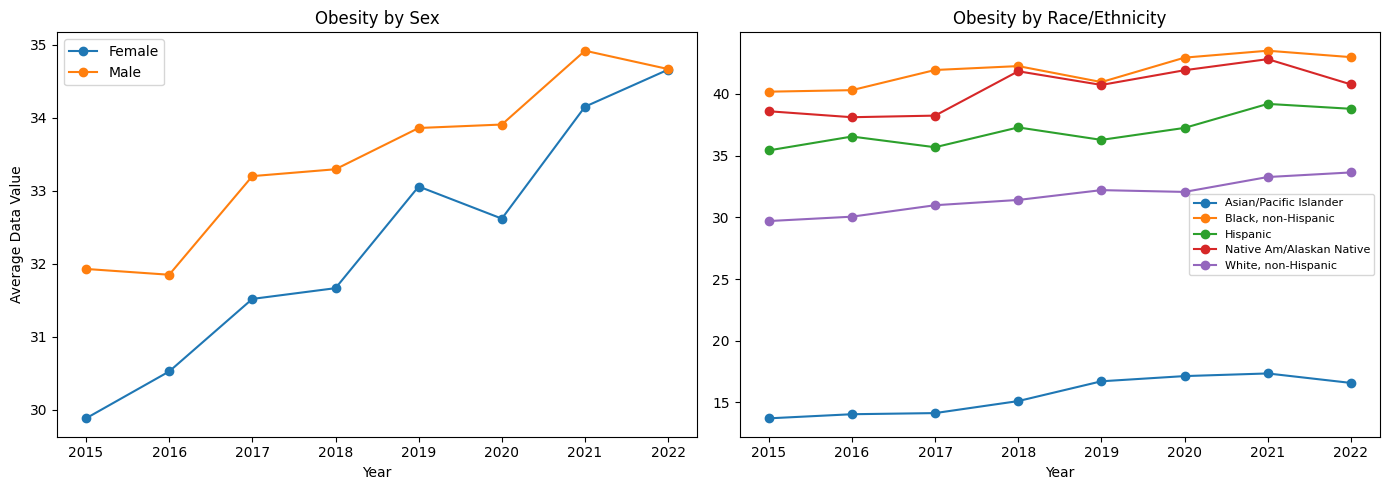

In [ ]:
# Choose one health condition
condition = "Obesity"

condition_df = filtered_df[filtered_df["Topic"] == condition]

# Separate the data
sex_df = condition_df[condition_df["Demographic"].isin(["Male", "Female"])]
race_df = condition_df[~condition_df["Demographic"].isin(["Male", "Female"])]

# Average by year
sex_year = sex_df.groupby(["Year", "Demographic"])["Data Value"].mean().reset_index()
race_year = race_df.groupby(["Year", "Demographic"])["Data Value"].mean().reset_index()

# Create two graphs in one figure
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Left graph: Male vs Female
for sex in sex_year["Demographic"].unique():
    temp = sex_year[sex_year["Demographic"] == sex]
    ax[0].plot(temp["Year"], temp["Data Value"], marker="o", label=sex)

ax[0].set_title("Obesity by Sex")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Average Data Value")
ax[0].legend()

# Right graph: Race/Ethnicity
for race in race_year["Demographic"].unique():
    temp = race_year[race_year["Demographic"] == race]
    ax[1].plot(temp["Year"], temp["Data Value"], marker="o", label=race)

ax[1].set_title("Obesity by Race/Ethnicity")
ax[1].set_xlabel("Year")
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{condition}_trend.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import os
import zipfile

png_files = [f for f in os.listdir() if f.endswith(".png")]

with zipfile.ZipFile("health_condition_graphs.zip", "w") as zipf:
    for file in png_files:
        zipf.write(file)

print("ZIP file created!")

ZIP file created!


In [ ]:
from google.colab import files

files.download("health_condition_graphs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Hypothesis Testing

In [ ]:
Null Hypothesis (H₀):
There is no statistically significant difference in the
prevalence of the selected health conditions among demographic groups of older adults in the United States from 2015 to 2022.

Alternative Hypothesis (H₁):
There is a statistically significant difference in the prevalence
of the selected health conditions among demographic groups of older adults in the United States from 2015 to 2022.

p-value < 0.05 -> reject H₀ -> significant difference
p-value ≥ 0.05 -> fail to reject H₀ -> no significant difference

SyntaxError: invalid character '₀' (U+2080) (524294800.py, line 1)

In [ ]:
from scipy.stats import ttest_ind

conditions = filtered_df["Topic"].unique()

print("Independent t-test Results for Male vs. Female")

for condition in conditions:

    condition_df = filtered_df[
        filtered_df["Topic"] == condition
    ]

    sex_df = condition_df[
        condition_df["Demographic"].isin(["Male", "Female"])
    ]

    male = sex_df[
        sex_df["Demographic"] == "Male"
    ]["Data Value"].dropna()

    female = sex_df[
        sex_df["Demographic"] == "Female"
    ]["Data Value"].dropna()

    if len(male) > 1 and len(female) > 1:

        t_stat, p = ttest_ind(
            male,
            female,
            equal_var=False
        )

        print(f"\n{condition}")
        print("t-statistic:", round(t_stat,3))
        print("p-value:",p)

Independent t-test Results for Male vs. Female

Lifetime diagnosis of depression
t-statistic: -38.502
p-value: 2.302145349056734e-224

Arthritis among older adults
t-statistic: -18.934
p-value: 3.583797278168745e-71

Obesity
t-statistic: 4.182
p-value: 3.025412925338946e-05

Current smoking
t-statistic: 6.997
p-value: 3.649825277738606e-12

Binge drinking within past 30 days
t-statistic: 27.615
p-value: 1.0334325649095495e-136

Functional difficulties associated with subjective cognitive decline or memory loss among older adults
t-statistic: -9.244
p-value: 1.9179151088867444e-19


In [ ]:
sex_breakdown = (
    filtered_df[
        filtered_df["Demographic"].isin(["Male", "Female"])
    ]
    .groupby(["Topic", "Demographic"])["Data Value"]
    .mean()
    .reset_index()
)

sex_breakdown

,Topic,Demographic,Data Value
0,Arthritis among older adults,Female,47.767816
1,Arthritis among older adults,Male,38.513997
2,Binge drinking within past 30 days,Female,6.317811
3,Binge drinking within past 30 days,Male,12.551630
4,Current smoking,Female,12.885060
5,Current smoking,Male,14.764527
6,Functional difficulties associated with subjec...,Female,40.530022
7,Functional difficulties associated with subjec...,Male,33.906030
8,Lifetime diagnosis of depression,Female,22.012650
9,Lifetime diagnosis of depression,Male,13.180437


In [ ]:
sex_table = sex_breakdown.pivot(index="Topic",columns="Demographic", values="Data Value")
sex_table

Demographic,Female,Male
Topic,,
Arthritis among older adults,47.767816,38.513997
Binge drinking within past 30 days,6.317811,12.551630
Current smoking,12.885060,14.764527
Functional difficulties associated with subjective cognitive decline or memory loss among older adults,40.530022,33.906030
Lifetime diagnosis of depression,22.012650,13.180437
Obesity,32.257651,33.447845


In [ ]:
from scipy.stats import f_oneway

conditions = filtered_df["Topic"].unique()

print("ANOVA Results for Race/Ethnicity")

for condition in conditions:

    # Filter for one health condition
    condition_df = filtered_df[filtered_df["Topic"] == condition]

    # Remove Male and Female
    race_df = condition_df[
        ~condition_df["Demographic"].isin(["Male", "Female"])
    ]

    # Groups
    groups = [
        group["Data Value"].dropna().values
        for _, group in race_df.groupby("Demographic")
    ]

    # Run ANOVA only if there are at least two race groups
    if len(groups) >= 2:

        F, p = f_oneway(*groups)

        print(f"\n{condition}")
        print("F-statistic:", round(F,3))
        print("P-value:", p)

ANOVA Results for Race/Ethnicity

Lifetime diagnosis of depression
F-statistic: 152.786
P-value: 3.064434949391219e-114

Arthritis among older adults
F-statistic: 132.691
P-value: 1.8385677125053987e-99

Obesity
F-statistic: 452.304
P-value: 8.513903166285699e-288

Current smoking
F-statistic: 307.643
P-value: 3.340699145627168e-204

Binge drinking within past 30 days
F-statistic: 12.274
P-value: 7.902046385113388e-10

Functional difficulties associated with subjective cognitive decline or memory loss among older adults
F-statistic: 76.356
P-value: 3.789045004979651e-55


In [ ]:
race_df = filtered_df[
    ~filtered_df["Demographic"].isin(["Male", "Female"])
]

In [ ]:
race_breakdown = (
    race_df
    .groupby(["Topic", "Demographic"])["Data Value"]
    .mean()
    .reset_index()
)

race_breakdown

,Topic,Demographic,Data Value
0,Arthritis among older adults,Asian/Pacific Islander,29.023881
1,Arthritis among older adults,"Black, non-Hispanic",45.897645
2,Arthritis among older adults,Hispanic,35.390860
3,Arthritis among older adults,Native Am/Alaskan Native,46.821341
4,Arthritis among older adults,"White, non-Hispanic",43.986519
5,Binge drinking within past 30 days,Asian/Pacific Islander,7.382667
6,Binge drinking within past 30 days,"Black, non-Hispanic",9.472355
7,Binge drinking within past 30 days,Hispanic,10.836681
8,Binge drinking within past 30 days,Native Am/Alaskan Native,12.123288
9,Binge drinking within past 30 days,"White, non-Hispanic",9.557765


In [ ]:
race_table = race_breakdown.pivot(
    index="Topic",
    columns="Demographic",
    values="Data Value"
)

race_table

Demographic,Asian/Pacific Islander,"Black, non-Hispanic",Hispanic,Native Am/Alaskan Native,"White, non-Hispanic"
Topic,,,,,
Arthritis among older adults,29.023881,45.897645,35.390860,46.821341,43.986519
Binge drinking within past 30 days,7.382667,9.472355,10.836681,12.123288,9.557765
Current smoking,9.238554,19.244444,12.905474,30.861585,13.249438
Functional difficulties associated with subjective cognitive decline or memory loss among older adults,42.118889,50.042373,57.241346,51.917647,32.986530
Lifetime diagnosis of depression,8.552273,16.012602,19.049072,24.614970,18.445241
Obesity,15.549123,41.869118,37.117197,40.424402,31.654181


# Tukey Test

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

conditions = filtered_df["Topic"].unique()

for condition in conditions:

    condition_df = filtered_df[
        filtered_df["Topic"] == condition
    ]

    race_df = condition_df[
        ~condition_df["Demographic"].isin(["Male", "Female"])
    ]

    tukey = pairwise_tukeyhsd(
        endog=race_df["Data Value"],
        groups=race_df["Demographic"],
        alpha=0.05
    )

    print("\n", condition)
    print(tukey)


 Lifetime diagnosis of depression
                  Multiple Comparison of Means - Tukey HSD, FWER=0.05                   
         group1                   group2          meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------------
  Asian/Pacific Islander      Black, non-Hispanic   7.4603    0.0    5.76  9.1606   True
  Asian/Pacific Islander                 Hispanic  10.4968    0.0  8.7576  12.236   True
  Asian/Pacific Islander Native Am/Alaskan Native  16.0627    0.0 14.1276 17.9978   True
  Asian/Pacific Islander      White, non-Hispanic    9.893    0.0  8.2516 11.5343   True
     Black, non-Hispanic                 Hispanic   3.0365    0.0  2.0309   4.042   True
     Black, non-Hispanic Native Am/Alaskan Native   8.6024    0.0  7.2867   9.918   True
     Black, non-Hispanic      White, non-Hispanic   2.4326    0.0  1.6078  3.2575   True
                Hispanic Native Am/Alaskan Native   5.5659    0.0  4.2003  